In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [10]:
from matplotlib.patches import Polygon

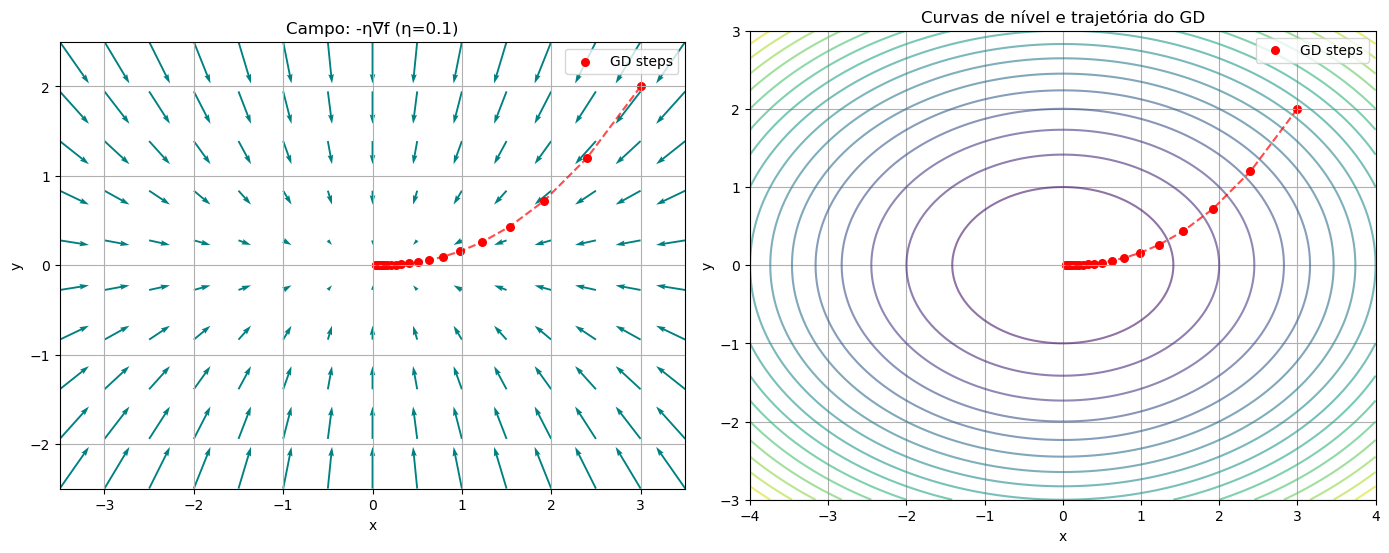

In [7]:
# Função e gradiente
def f(x, y):
    return x**2 + 2*y**2

def grad_f(x, y):
    return np.array([2*x, 4*y])

# Parâmetros
learning_rate = 0.1
max_iterations = 20
start_point = np.array([3.0, 2.0])

# Gradient Descent
points = [start_point]
for _ in range(max_iterations):
    last_point = points[-1]
    gradient = grad_f(last_point[0], last_point[1])
    new_point = last_point - learning_rate * gradient
    points.append(new_point)
points = np.array(points)

# Configuração dos plots
plt.figure(figsize=(14, 6))

# --- Plot 1: Campo -learning_rate*∇f ---
ax1 = plt.subplot(1, 2, 1)

# Grid principal (visível)
x_visible = np.linspace(-3.5, 3.5, 15)
y_visible = np.linspace(-2.5, 2.5, 10)
X_vis, Y_vis = np.meshgrid(x_visible, y_visible)

# Flechas do grid visível (com -learning_rate*∇f)
grad_vis_x, grad_vis_y = -learning_rate * grad_f(X_vis, Y_vis)
ax1.quiver(X_vis, Y_vis, grad_vis_x, grad_vis_y, 
           color='teal', scale=15, width=0.003, headwidth=3)

# Trajetória do GD
ax1.scatter(points[:, 0], points[:, 1], c='red', s=30, label='GD steps')
ax1.plot(points[:, 0], points[:, 1], 'r--', alpha=0.7)
ax1.set_title(f'Campo: -η∇f (η={learning_rate})')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.legend()
ax1.grid(True)
ax1.set_aspect('equal')
ax1.set_xlim(-3.5, 3.5)
ax1.set_ylim(-2.5, 2.5)

# --- Plot 2: Curvas de nível ---
ax2 = plt.subplot(1, 2, 2)
x_contour = np.linspace(-4, 4, 100)
y_contour = np.linspace(-3, 3, 100)
X_contour, Y_contour = np.meshgrid(x_contour, y_contour)
Z_contour = f(X_contour, Y_contour)
ax2.contour(X_contour, Y_contour, Z_contour, levels=20, cmap='viridis', alpha=0.6)
ax2.scatter(points[:, 0], points[:, 1], c='red', s=30, label='GD steps')
ax2.plot(points[:, 0], points[:, 1], 'r--', alpha=0.7)
ax2.set_title('Curvas de nível e trajetória do GD')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.legend()
ax2.grid(True)
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()

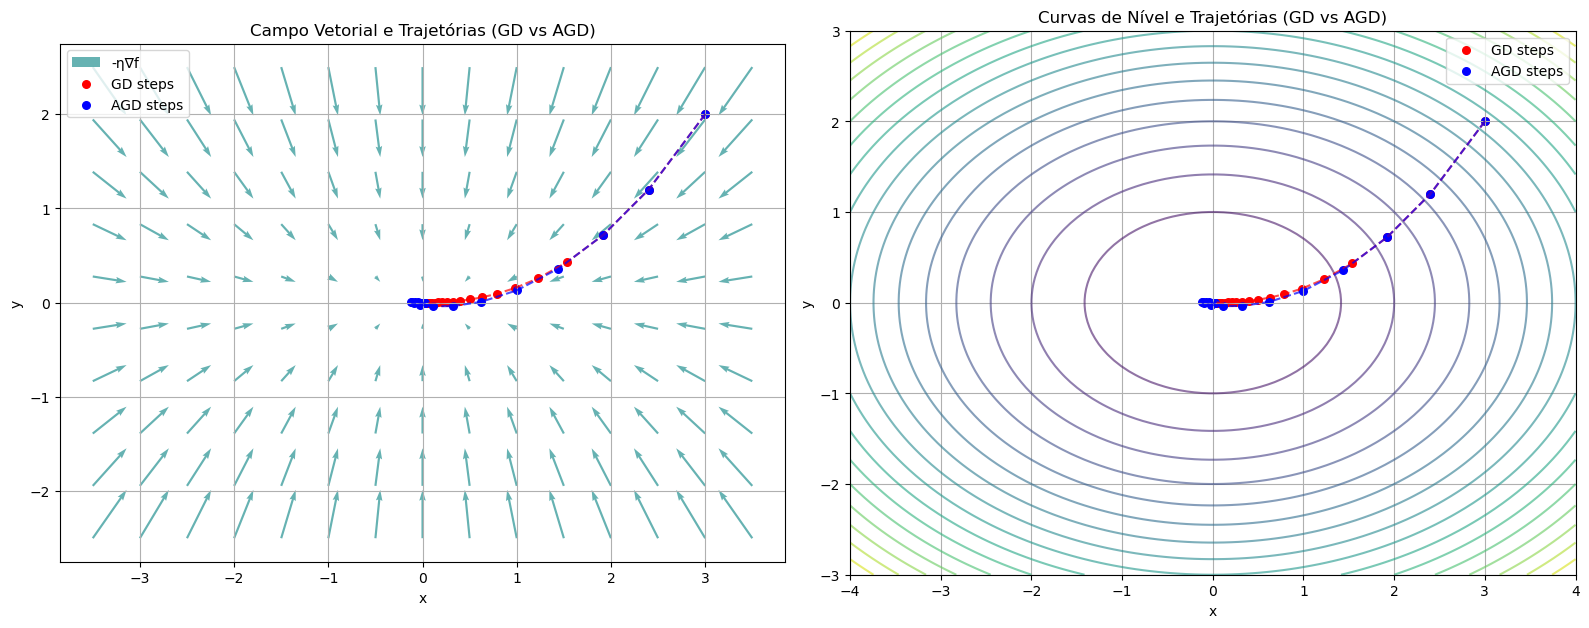

In [8]:
# Função e gradiente
def f(x, y):
    return x**2 + 2*y**2

def grad_f(x, y):
    return np.array([2*x, 4*y])

# Parâmetros
learning_rate = 0.1
max_iterations = 20
start_point = np.array([3.0, 2.0])

# --- GD (Gradient Descent) ---
gd_points = [start_point]
for _ in range(max_iterations):
    last_point = gd_points[-1]
    gradient = grad_f(last_point[0], last_point[1])
    new_point = last_point - learning_rate * gradient
    gd_points.append(new_point)
gd_points = np.array(gd_points)

# --- AGD (Accelerated Gradient Descent) ---
agd_points = [start_point]
y_points = [start_point.copy()]  # y_k
x_prev = start_point.copy()      # x_{k-1}

for k in range(1, max_iterations + 1):
    # Atualiza x_{k+1} = y_k - η∇f(y_k)
    y_k = y_points[-1]
    gradient = grad_f(y_k[0], y_k[1])
    x_new = y_k - learning_rate * gradient
    agd_points.append(x_new)
    
    # Calcula μ_k = (k-1)/(k+2)
    mu_k = (k - 1) / (k + 2)
    
    # Atualiza y_{k+1} = x_{k+1} + μ_k(x_{k+1} - x_k)
    y_new = x_new + mu_k * (x_new - x_prev)
    y_points.append(y_new)
    
    # Prepara para próxima iteração
    x_prev = x_new.copy()

agd_points = np.array(agd_points)

# Configuração dos plots
plt.figure(figsize=(16, 6))

# --- Plot 1: Campo -η∇f ---
ax1 = plt.subplot(1, 2, 1)
x_visible = np.linspace(-3.5, 3.5, 15)
y_visible = np.linspace(-2.5, 2.5, 10)
X_vis, Y_vis = np.meshgrid(x_visible, y_visible)

# Flechas do campo (GD)
grad_vis_x, grad_vis_y = -learning_rate * grad_f(X_vis, Y_vis)
ax1.quiver(X_vis, Y_vis, grad_vis_x, grad_vis_y, 
           color='teal', scale=15, width=0.003, alpha=0.6, label='-η∇f')

# Trajetórias
ax1.scatter(gd_points[:, 0], gd_points[:, 1], c='red', s=30, label='GD steps')
ax1.plot(gd_points[:, 0], gd_points[:, 1], 'r--', alpha=0.7)
ax1.scatter(agd_points[:, 0], agd_points[:, 1], c='blue', s=30, label='AGD steps')
ax1.plot(agd_points[:, 0], agd_points[:, 1], 'b--', alpha=0.7)

ax1.set_title('Campo Vetorial e Trajetórias (GD vs AGD)')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.legend()
ax1.grid(True)
ax1.set_aspect('equal')

# --- Plot 2: Curvas de Nível ---
ax2 = plt.subplot(1, 2, 2)
x_contour = np.linspace(-4, 4, 100)
y_contour = np.linspace(-3, 3, 100)
X_contour, Y_contour = np.meshgrid(x_contour, y_contour)
Z_contour = f(X_contour, Y_contour)
ax2.contour(X_contour, Y_contour, Z_contour, levels=20, cmap='viridis', alpha=0.6)

# Trajetórias
ax2.scatter(gd_points[:, 0], gd_points[:, 1], c='red', s=30, label='GD steps')
ax2.plot(gd_points[:, 0], gd_points[:, 1], 'r--', alpha=0.7)
ax2.scatter(agd_points[:, 0], agd_points[:, 1], c='blue', s=30, label='AGD steps')
ax2.plot(agd_points[:, 0], agd_points[:, 1], 'b--', alpha=0.7)

ax2.set_title('Curvas de Nível e Trajetórias (GD vs AGD)')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.legend()
ax2.grid(True)
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()

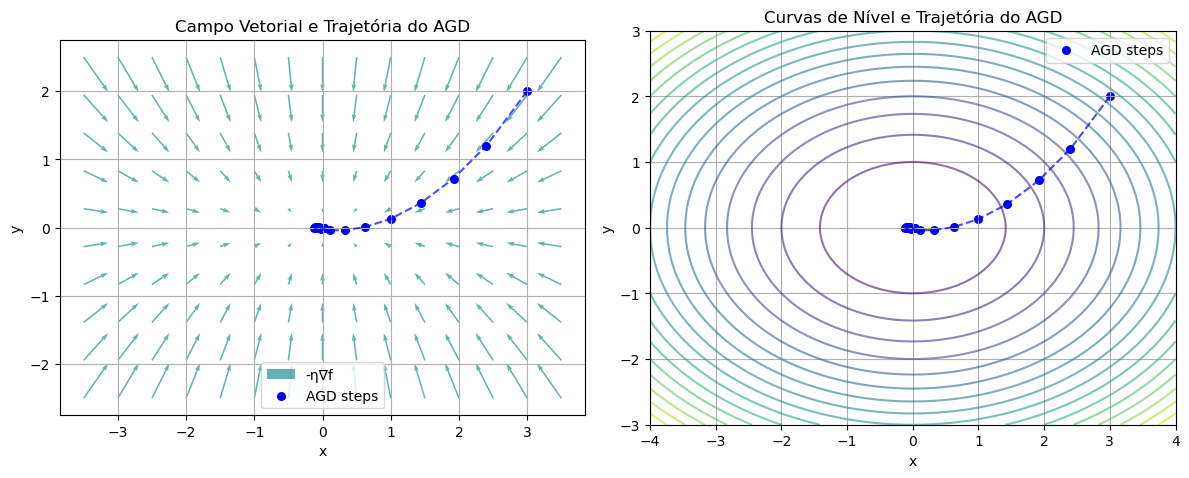

In [9]:
# Função e gradiente
def f(x, y):
    return x**2 + 2*y**2

def grad_f(x, y):
    return np.array([2*x, 4*y])

# Parâmetros
learning_rate = 0.1
max_iterations = 20
start_point = np.array([3.0, 2.0])

# --- AGD (Accelerated Gradient Descent) ---
agd_points = [start_point]
y_points = [start_point.copy()]  # y_k
x_prev = start_point.copy()      # x_{k-1}

for k in range(1, max_iterations + 1):
    # Atualiza x_{k+1} = y_k - η∇f(y_k)
    y_k = y_points[-1]
    gradient = grad_f(y_k[0], y_k[1])
    x_new = y_k - learning_rate * gradient
    agd_points.append(x_new)
    
    # Calcula μ_k = (k-1)/(k+2)
    mu_k = (k - 1) / (k + 2)
    
    # Atualiza y_{k+1} = x_{k+1} + μ_k(x_{k+1} - x_k)
    y_new = x_new + mu_k * (x_new - x_prev)
    y_points.append(y_new)
    
    # Prepara para próxima iteração
    x_prev = x_new.copy()

agd_points = np.array(agd_points)

# Configuração do plot
plt.figure(figsize=(12, 6))

# --- Plot 1: Campo -η∇f ---
ax1 = plt.subplot(1, 2, 1)
x_visible = np.linspace(-3.5, 3.5, 15)
y_visible = np.linspace(-2.5, 2.5, 10)
X_vis, Y_vis = np.meshgrid(x_visible, y_visible)

# Flechas do campo
grad_vis_x, grad_vis_y = -learning_rate * grad_f(X_vis, Y_vis)
ax1.quiver(X_vis, Y_vis, grad_vis_x, grad_vis_y, 
           color='teal', scale=15, width=0.003, alpha=0.6, label='-η∇f')

# Trajetória do AGD
ax1.scatter(agd_points[:, 0], agd_points[:, 1], c='blue', s=30, label='AGD steps')
ax1.plot(agd_points[:, 0], agd_points[:, 1], 'b--', alpha=0.7)

ax1.set_title('Campo Vetorial e Trajetória do AGD')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.legend()
ax1.grid(True)
ax1.set_aspect('equal')

# --- Plot 2: Curvas de Nível ---
ax2 = plt.subplot(1, 2, 2)
x_contour = np.linspace(-4, 4, 100)
y_contour = np.linspace(-3, 3, 100)
X_contour, Y_contour = np.meshgrid(x_contour, y_contour)
Z_contour = f(X_contour, Y_contour)
ax2.contour(X_contour, Y_contour, Z_contour, levels=20, cmap='viridis', alpha=0.6)

# Trajetória do AGD
ax2.scatter(agd_points[:, 0], agd_points[:, 1], c='blue', s=30, label='AGD steps')
ax2.plot(agd_points[:, 0], agd_points[:, 1], 'b--', alpha=0.7)

ax2.set_title('Curvas de Nível e Trajetória do AGD')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.legend()
ax2.grid(True)
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()

C:\Users\josea\AppData\Local\Temp\ipykernel_2588\1664656147.py:94: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from current font.
  plt.tight_layout()
C:\Users\josea\AppData\Local\Temp\ipykernel_2588\1664656147.py:94: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  plt.tight_layout()
C:\Users\josea\AppData\Local\Temp\ipykernel_2588\1664656147.py:94: UserWarning: Glyph 8711 (\N{NABLA}) missing from current font.
  plt.tight_layout()
C:\Users\josea\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\josea\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8711 (\N{NABLA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\josea\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from current font.
  fig.canvas.prin

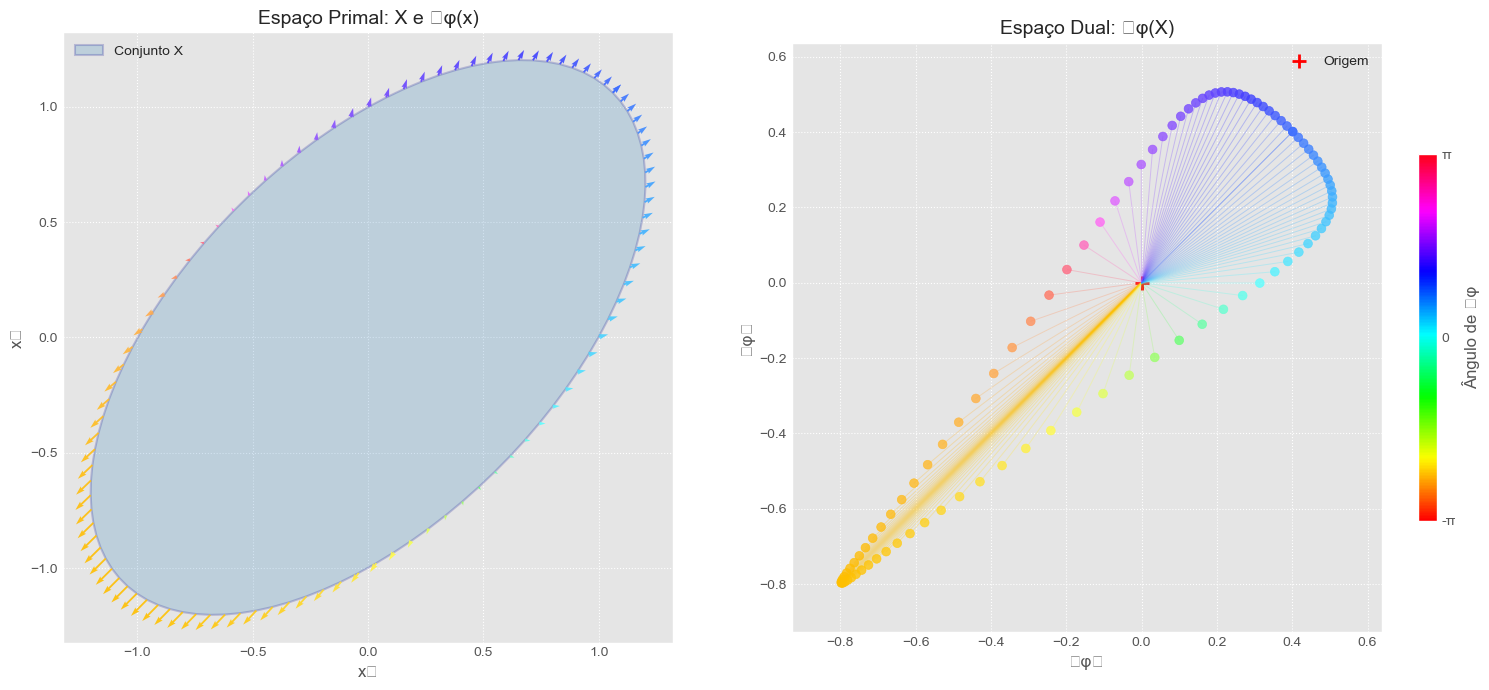

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb
from scipy.optimize import minimize

# 1. Configurações iniciais
plt.style.use('ggplot')  # Estilo visual moderno
np.random.seed(42)

# 2. Definir função φ estritamente convexa (exemplo: log-sum-exp)
def phi(x, y):
    return np.log(np.exp(x) + np.exp(y) + np.exp(-x-y) + 1)

def grad_phi(x, y):
    exp_x = np.exp(x)
    exp_y = np.exp(y)
    exp_neg = np.exp(-x-y)
    denom = exp_x + exp_y + exp_neg + 1
    return np.array([exp_x/denom - exp_neg/denom, 
                    exp_y/denom - exp_neg/denom])

# 3. Criar conjunto convexo X (elipse alongada rotacionada)
theta = np.linspace(0, 2*np.pi, 100)
a, b = 1.5, 0.8  # Semi-eixos
rotation = np.pi/4  # Rotação de 45 graus
x_boundary = a*np.cos(theta)*np.cos(rotation) - b*np.sin(theta)*np.sin(rotation)
y_boundary = a*np.cos(theta)*np.sin(rotation) + b*np.sin(theta)*np.cos(rotation)
boundary_points = np.column_stack((x_boundary, y_boundary))

# 4. Calcular gradientes nos pontos do bordo
gradients = np.array([grad_phi(p[0], p[1]) for p in boundary_points])

# 5. Configurar cores baseadas no ângulo e magnitude
angles = np.arctan2(gradients[:,1], gradients[:,0])
magnitudes = np.linalg.norm(gradients, axis=1)

# Normalização para cores HSV
h = (angles + np.pi) / (2*np.pi)  # Matiz pelo ângulo
s = 0.5 + 0.5*(magnitudes / magnitudes.max())  # Saturação pela magnitude
colors = hsv_to_rgb(np.column_stack((h, s, np.ones_like(h))))

# 6. Criar figura
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# --- Plot Primal ---
# Conjunto X
ax1.fill(boundary_points[:,0], boundary_points[:,1], '#1f77b4', alpha=0.2, 
         edgecolor='darkblue', linewidth=1.5, label='Conjunto X')

# Gradientes no bordo (setas menores)
for point, grad, color in zip(boundary_points, gradients, colors):
    ax1.quiver(point[0], point[1], grad[0], grad[1], 
               color=color, scale=30, width=0.003, alpha=0.9)

ax1.set_title('Espaço Primal: X e ∇φ(x)', fontsize=14)
ax1.set_xlabel('x₁', fontsize=12)
ax1.set_ylabel('x₂', fontsize=12)
ax1.legend()
ax1.set_aspect('equal')
ax1.grid(True, linestyle=':')

# --- Plot Dual ---
# Calcular limites dinâmicos para o espaço dual
dual_min = np.min(gradients, axis=0)
dual_max = np.max(gradients, axis=0)
padding = 0.1 * (dual_max - dual_min)

# Plotar pontos duais como scatter plot colorido
ax2.scatter(gradients[:,0], gradients[:,1], c=colors, s=40, alpha=0.8)

# Destacar origem
ax2.scatter([0], [0], c='red', s=100, marker='+', linewidth=2, label='Origem')

# Linhas da origem aos pontos duais (opcional)
for grad, color in zip(gradients, colors):
    ax2.plot([0, grad[0]], [0, grad[1]], color=color, alpha=0.3, linewidth=0.7)

ax2.set_title('Espaço Dual: ∇φ(X)', fontsize=14)
ax2.set_xlabel('∇φ₁', fontsize=12)
ax2.set_ylabel('∇φ₂', fontsize=12)
ax2.legend()
ax2.set_aspect('equal')
ax2.grid(True, linestyle=':')
ax2.set_xlim(dual_min[0]-padding[0], dual_max[0]+padding[0])
ax2.set_ylim(dual_min[1]-padding[1], dual_max[1]+padding[1])

# Barra de cores para ângulo
cbar = plt.colorbar(plt.cm.ScalarMappable(
    norm=plt.Normalize(-np.pi, np.pi), 
    cmap='hsv'), ax=ax2, shrink=0.6, label='Ângulo de ∇φ')
cbar.set_ticks([-np.pi, 0, np.pi])
cbar.set_ticklabels(['-π', '0', 'π'])

plt.tight_layout()
plt.show()

Ponto ótimo de φ: [-0.29867889 -0.29867889]


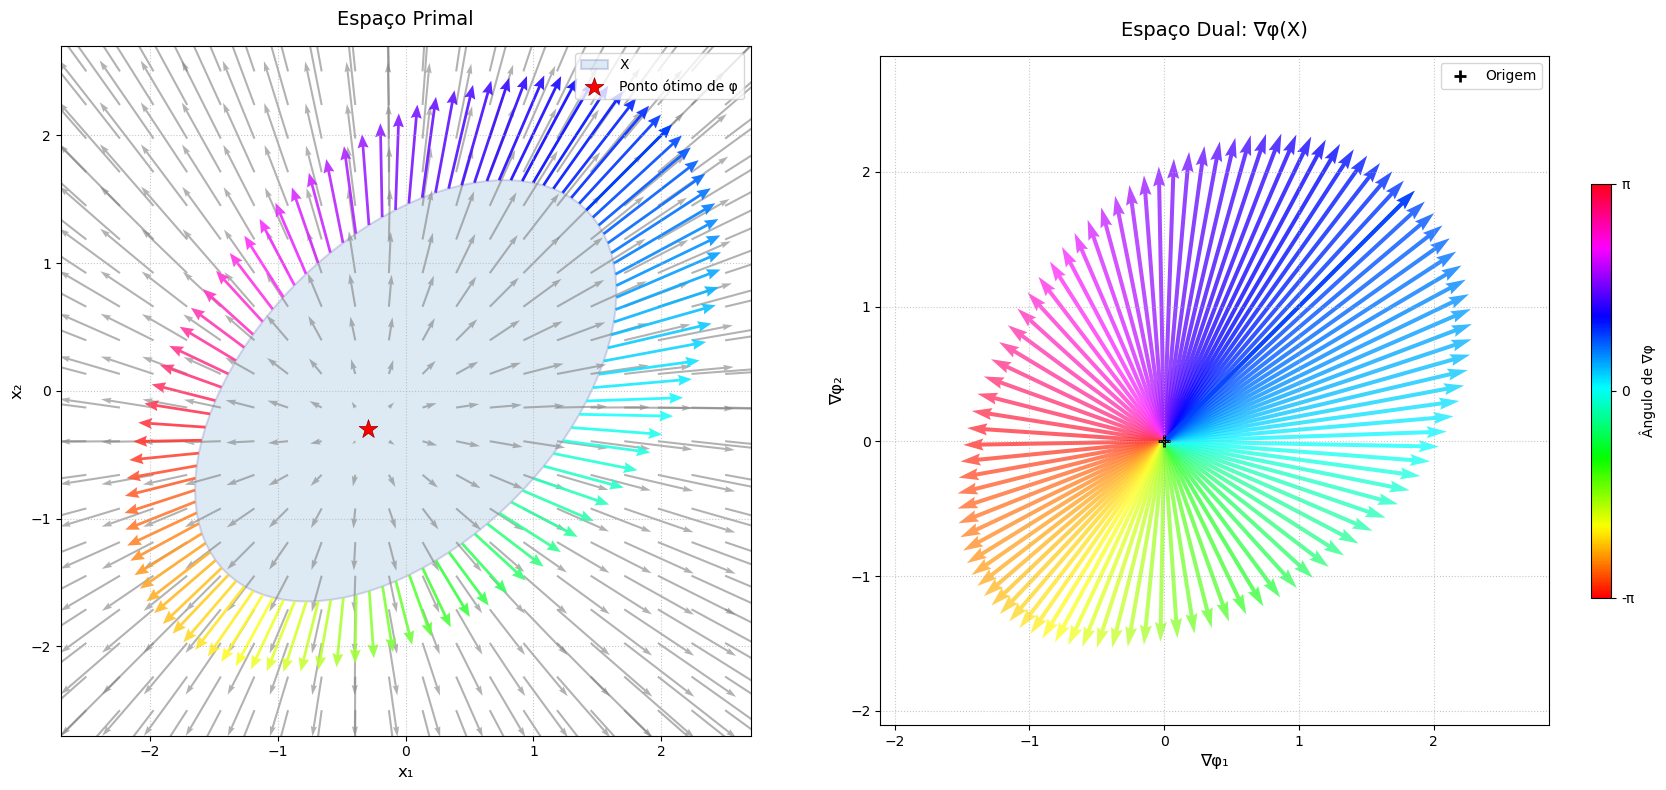

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb
from scipy.optimize import minimize

# 1. Configurações iniciais
plt.style.use('default')  # Fundo branco puro
plt.rcParams['figure.facecolor'] = 'white'
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), facecolor='white')

# 2. Função φ estritamente convexa (modificada para ter mínimo claro)
def phi(x, y):
    return 0.5*(x**2 + y**2) + np.log(np.exp(x) + np.exp(y) + 1)

def grad_phi(x, y):
    exp_x = np.exp(x)
    exp_y = np.exp(y)
    denom = exp_x + exp_y + 1
    return np.array([x + exp_x/denom, 
                    y + exp_y/denom])

# 3. Encontrar ponto ótimo de φ
res = minimize(lambda p: phi(p[0], p[1]), x0=[0,0])
optimal_phi = res.x
print(f"Ponto ótimo de φ: {optimal_phi}")

# 4. Conjunto convexo X (elipse com rotação)
theta = np.linspace(0, 2*np.pi, 100)
a, b = 2.0, 1.2  # Semi-eixos
rotation = np.pi/4
x_boundary = a*np.cos(theta)*np.cos(rotation) - b*np.sin(theta)*np.sin(rotation)
y_boundary = a*np.cos(theta)*np.sin(rotation) + b*np.sin(theta)*np.cos(rotation)
boundary_points = np.column_stack((x_boundary, y_boundary))

# 5. Calcular gradientes e cores
gradients = np.array([grad_phi(p[0], p[1]) for p in boundary_points])
magnitudes = np.linalg.norm(gradients, axis=1)
angles = np.arctan2(gradients[:,1], gradients[:,0])

# Configuração de cores
h = (angles + np.pi) / (2*np.pi)
s = 0.5 + 0.5*(magnitudes/magnitudes.max())
colors = hsv_to_rgb(np.column_stack((h, s, np.ones_like(h))))

# --- Plot Primal ---
# Conjunto X
ax1.fill(boundary_points[:,0], boundary_points[:,1], '#1f77b4', alpha=0.15, 
         edgecolor='darkblue', linewidth=1.5, label='X')

# Campo gradiente (20x20 grid)
X, Y = np.meshgrid(np.linspace(-2.5, 2.5, 20), np.linspace(-2.5, 2.5, 20))
U, V = np.zeros_like(X), np.zeros_like(Y)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        grad = grad_phi(X[i,j], Y[i,j])
        U[i,j], V[i,j] = grad[0], grad[1]
        
ax1.quiver(X, Y, U, V, color='gray', scale=25, width=0.003, alpha=0.6)

# Gradientes no bordo (setas maiores)
for point, grad, color in zip(boundary_points, gradients, colors):
    ax1.quiver(point[0], point[1], grad[0], grad[1], 
               color=color, scale=15, width=0.004, alpha=0.9,
               headwidth=4, headlength=5)

# Ponto ótimo de φ
ax1.scatter(*optimal_phi, c='red', s=200, marker='*', 
            edgecolor='darkred', linewidth=0.5, label='Ponto ótimo de φ')

ax1.set_title('Espaço Primal', fontsize=14, pad=15)
ax1.set_xlabel('x₁', fontsize=12)
ax1.set_ylabel('x₂', fontsize=12)
ax1.legend(loc='upper right')
ax1.set_aspect('equal')
ax1.grid(True, linestyle=':', alpha=0.7)
ax1.set_xlim(-2.7, 2.7)
ax1.set_ylim(-2.7, 2.7)

# --- Plot Dual ---
# Calcular limites com padding
dual_min = np.min(gradients, axis=0)
dual_max = np.max(gradients, axis=0)
padding = 0.15 * (dual_max - dual_min)

# Plotar como setas da origem
for grad, color in zip(gradients, colors):
    ax2.quiver(0, 0, grad[0], grad[1], 
               color=color, scale=1, width=0.006, 
               angles='xy', scale_units='xy', alpha=0.8)

# Destacar origem
ax2.scatter(0, 0, c='black', s=80, marker='+', linewidth=2, label='Origem')

ax2.set_title('Espaço Dual: ∇φ(X)', fontsize=14, pad=15)
ax2.set_xlabel('∇φ₁', fontsize=12)
ax2.set_ylabel('∇φ₂', fontsize=12)
ax2.legend()
ax2.set_aspect('equal')
ax2.grid(True, linestyle=':', alpha=0.7)
ax2.set_xlim(dual_min[0]-padding[0], dual_max[0]+padding[0])
ax2.set_ylim(dual_min[1]-padding[1], dual_max[1]+padding[1])

# Barra de cores para ângulo
cbar = plt.colorbar(plt.cm.ScalarMappable(
    norm=plt.Normalize(-np.pi, np.pi), 
    cmap='hsv'), ax=ax2, shrink=0.6, label='Ângulo de ∇φ')
cbar.set_ticks([-np.pi, 0, np.pi])
cbar.set_ticklabels(['-π', '0', 'π'])

plt.tight_layout()
plt.show()

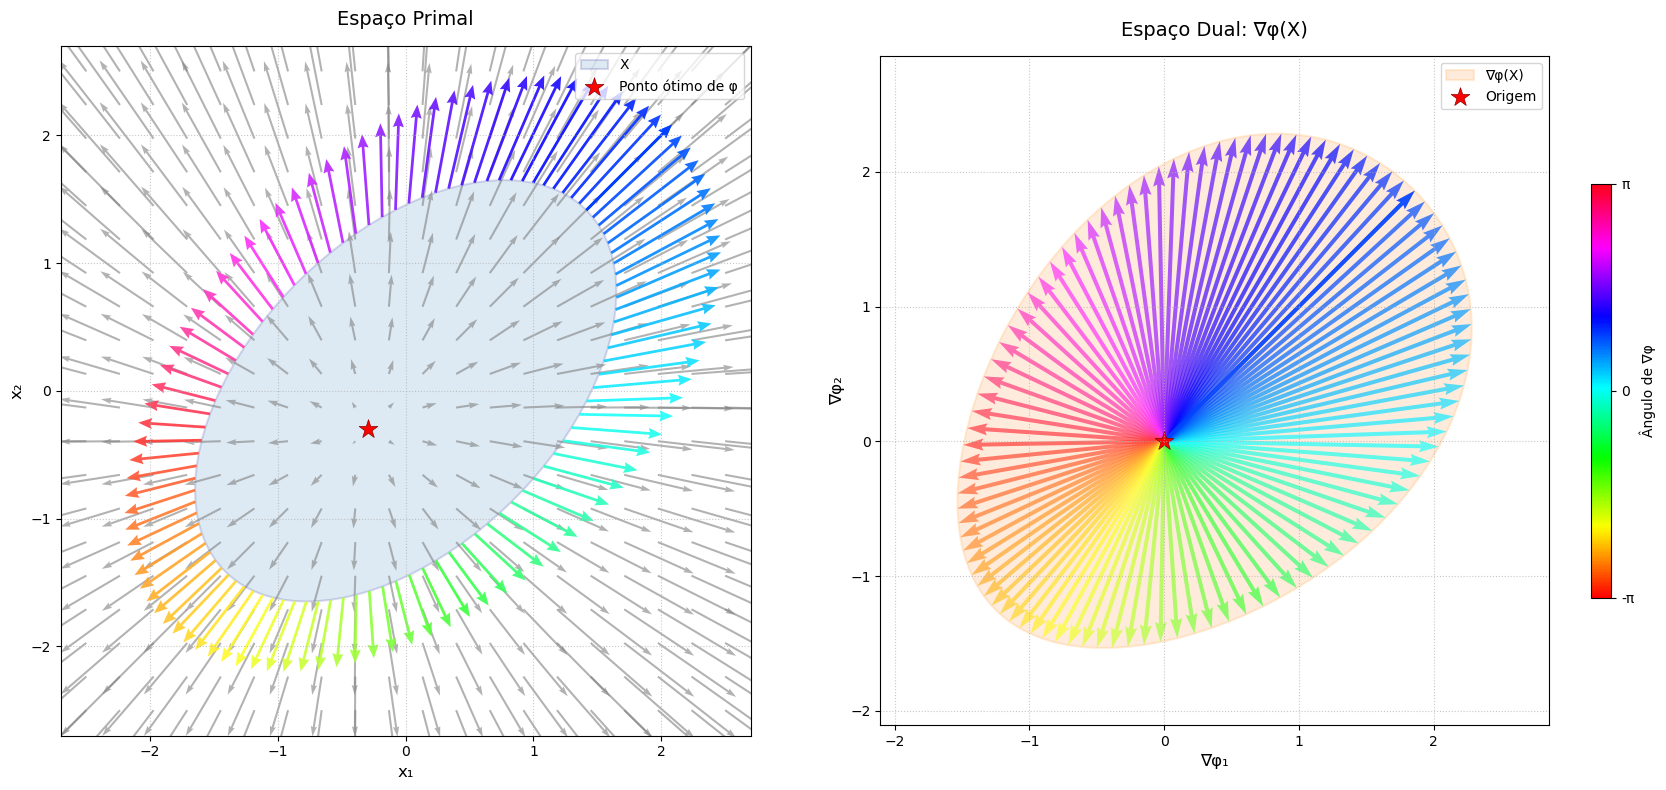

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb
from scipy.optimize import minimize

# 1. Configurações iniciais
plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), facecolor='white')

# 2. Função φ e gradiente
def phi(x, y):
    return 0.5*(x**2 + y**2) + np.log(np.exp(x) + np.exp(y) + 1)

def grad_phi(x, y):
    exp_x = np.exp(x)
    exp_y = np.exp(y)
    denom = exp_x + exp_y + 1
    return np.array([x + exp_x/denom, 
                    y + exp_y/denom])

# 3. Ponto ótimo de φ
res = minimize(lambda p: phi(p[0], p[1]), x0=[0,0])
optimal_phi = res.x

# 4. Conjunto convexo X (elipse rotacionada)
theta = np.linspace(0, 2*np.pi, 100)
a, b = 2.0, 1.2
rotation = np.pi/4
x_boundary = a*np.cos(theta)*np.cos(rotation) - b*np.sin(theta)*np.sin(rotation)
y_boundary = a*np.cos(theta)*np.sin(rotation) + b*np.sin(theta)*np.cos(rotation)
boundary_points = np.column_stack((x_boundary, y_boundary))

# 5. Calcular gradientes e cores
gradients = np.array([grad_phi(p[0], p[1]) for p in boundary_points])
magnitudes = np.linalg.norm(gradients, axis=1)
angles = np.arctan2(gradients[:,1], gradients[:,0])

# Configuração de cores
h = (angles + np.pi) / (2*np.pi)
s = 0.5 + 0.5*(magnitudes/magnitudes.max())
colors = hsv_to_rgb(np.column_stack((h, s, np.ones_like(h))))

# --- Plot Primal ---
# Conjunto X
ax1.fill(boundary_points[:,0], boundary_points[:,1], '#1f77b4', alpha=0.15, 
         edgecolor='darkblue', linewidth=1.5, label='X')

# Campo gradiente
X, Y = np.meshgrid(np.linspace(-2.5, 2.5, 20), np.linspace(-2.5, 2.5, 20))
U, V = np.zeros_like(X), np.zeros_like(Y)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        grad = grad_phi(X[i,j], Y[i,j])
        U[i,j], V[i,j] = grad[0], grad[1]
        
ax1.quiver(X, Y, U, V, color='gray', scale=25, width=0.003, alpha=0.6)

# Gradientes no bordo
for point, grad, color in zip(boundary_points, gradients, colors):
    ax1.quiver(point[0], point[1], grad[0], grad[1], 
               color=color, scale=15, width=0.004, alpha=0.9,
               headwidth=4, headlength=5)

# Ponto ótimo de φ
ax1.scatter(*optimal_phi, c='red', s=200, marker='*', 
            edgecolor='darkred', linewidth=0.5, label='Ponto ótimo de φ')

ax1.set_title('Espaço Primal', fontsize=14, pad=15)
ax1.set_xlabel('x₁', fontsize=12)
ax1.set_ylabel('x₂', fontsize=12)
ax1.legend(loc='upper right')
ax1.set_aspect('equal')
ax1.grid(True, linestyle=':', alpha=0.7)
ax1.set_xlim(-2.7, 2.7)
ax1.set_ylim(-2.7, 2.7)

# --- Plot Dual ---
# Contorno do conjunto transformado (fechando o ciclo)
dual_points = gradients
ax2.fill(dual_points[:,0], dual_points[:,1], '#ff7f0e', alpha=0.15, 
         edgecolor='darkorange', linewidth=1.5, label='∇φ(X)')

# Setas da origem (manter cores correspondentes)
for grad, color in zip(gradients, colors):
    ax2.quiver(0, 0, grad[0], grad[1], 
               color=color, scale=1, width=0.006, 
               angles='xy', scale_units='xy', alpha=0.7)

# Origem como estrela vermelha (igual ao primal)
ax2.scatter(0, 0, c='red', s=200, marker='*', 
            edgecolor='darkred', linewidth=0.5, label='Origem')

ax2.set_title('Espaço Dual: ∇φ(X)', fontsize=14, pad=15)
ax2.set_xlabel('∇φ₁', fontsize=12)
ax2.set_ylabel('∇φ₂', fontsize=12)
ax2.legend()
ax2.set_aspect('equal')
ax2.grid(True, linestyle=':', alpha=0.7)

# Ajustar limites dinamicamente com padding
dual_min = np.min(gradients, axis=0)
dual_max = np.max(gradients, axis=0)
padding = 0.15 * (dual_max - dual_min)
ax2.set_xlim(dual_min[0]-padding[0], dual_max[0]+padding[0])
ax2.set_ylim(dual_min[1]-padding[1], dual_max[1]+padding[1])

# Barra de cores
cbar = plt.colorbar(plt.cm.ScalarMappable(
    norm=plt.Normalize(-np.pi, np.pi), 
    cmap='hsv'), ax=ax2, shrink=0.6, label='Ângulo de ∇φ')
cbar.set_ticks([-np.pi, 0, np.pi])
cbar.set_ticklabels(['-π', '0', 'π'])

plt.tight_layout()
plt.show()

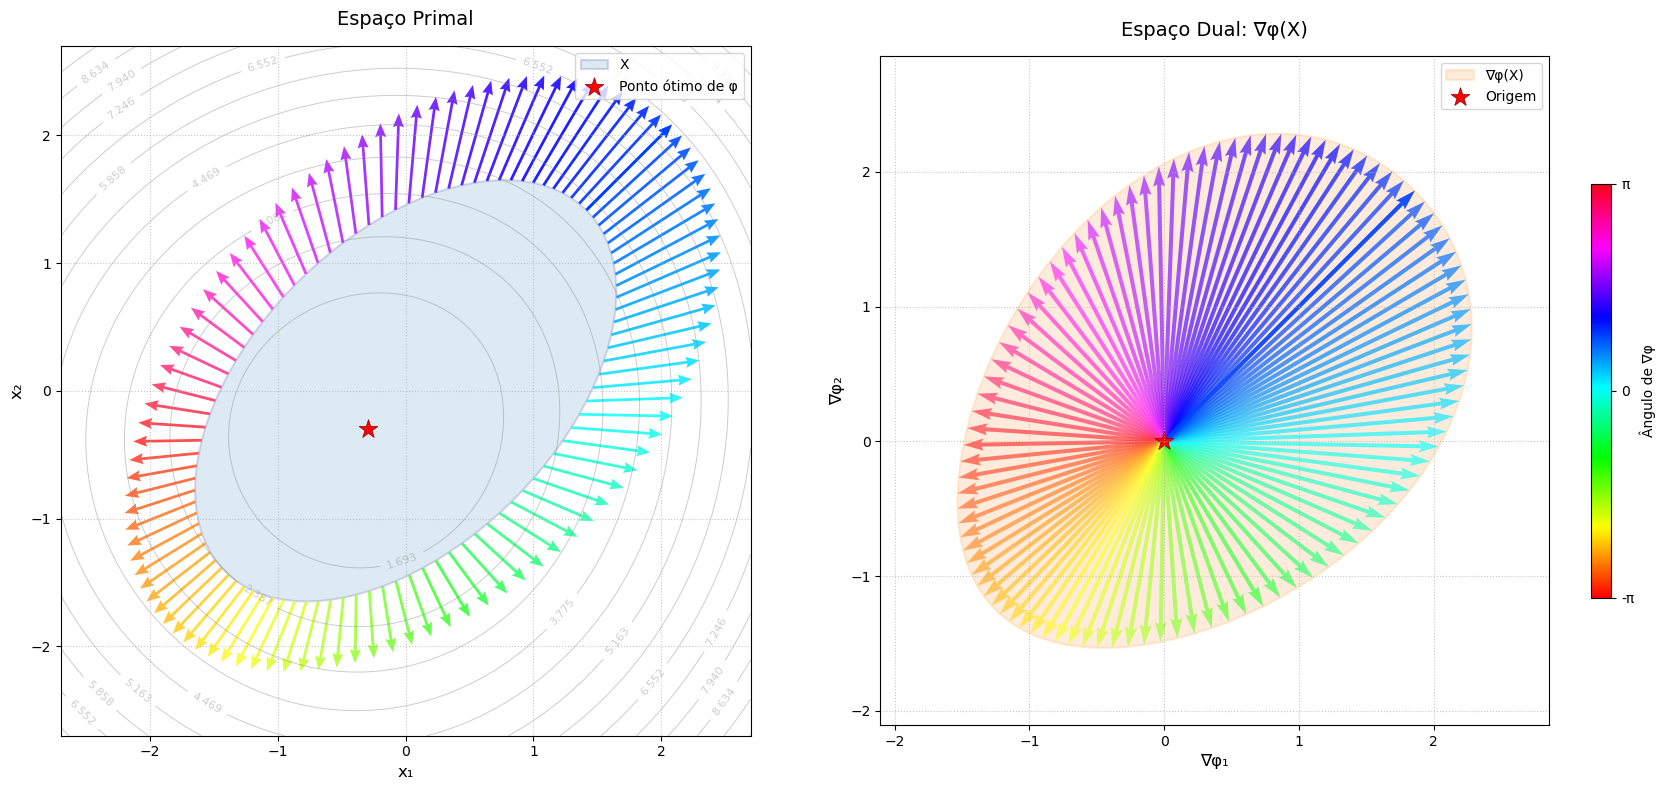

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb
from scipy.optimize import minimize

# 1. Configurações iniciais
plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), facecolor='white')

# 2. Função φ e gradiente (convexas)
def phi(x, y):
    return 0.5*(x**2 + y**2) + np.log(np.exp(x) + np.exp(y) + 1)

def grad_phi(x, y):
    exp_x = np.exp(x)
    exp_y = np.exp(y)
    denom = exp_x + exp_y + 1
    return np.array([x + exp_x/denom, 
                    y + exp_y/denom])

# 3. Ponto ótimo de φ
res = minimize(lambda p: phi(p[0], p[1]), x0=[0,0])
optimal_phi = res.x

# 4. Conjunto convexo X (elipse rotacionada)
theta = np.linspace(0, 2*np.pi, 100)
a, b = 2.0, 1.2
rotation = np.pi/4
x_boundary = a*np.cos(theta)*np.cos(rotation) - b*np.sin(theta)*np.sin(rotation)
y_boundary = a*np.cos(theta)*np.sin(rotation) + b*np.sin(theta)*np.cos(rotation)
boundary_points = np.column_stack((x_boundary, y_boundary))

# 5. Calcular gradientes e cores
gradients = np.array([grad_phi(p[0], p[1]) for p in boundary_points])
magnitudes = np.linalg.norm(gradients, axis=1)
angles = np.arctan2(gradients[:,1], gradients[:,0])

# Configuração de cores HSV
h = (angles + np.pi) / (2*np.pi)
s = 0.5 + 0.5*(magnitudes/magnitudes.max())
colors = hsv_to_rgb(np.column_stack((h, s, np.ones_like(h))))

# --- Plot Primal ---
# Curvas de nível de φ
x_vals = np.linspace(-2.7, 2.7, 100)
y_vals = np.linspace(-2.7, 2.7, 100)
X, Y = np.meshgrid(x_vals, y_vals)
Z = phi(X, Y)

levels = np.linspace(Z.min(), Z.max(), 15)
contour = ax1.contour(X, Y, Z, levels=levels, colors='gray', alpha=0.4, linewidths=0.7)
ax1.clabel(contour, inline=True, fontsize=8)

# Conjunto X
ax1.fill(boundary_points[:,0], boundary_points[:,1], '#1f77b4', alpha=0.15, 
         edgecolor='darkblue', linewidth=1.5, label='X')

# Gradientes no bordo (setas coloridas)
for point, grad, color in zip(boundary_points, gradients, colors):
    ax1.quiver(point[0], point[1], grad[0], grad[1], 
               color=color, scale=15, width=0.004, alpha=0.9,
               headwidth=4, headlength=5)

# Ponto ótimo de φ
ax1.scatter(*optimal_phi, c='red', s=200, marker='*', 
            edgecolor='darkred', linewidth=0.5, label='Ponto ótimo de φ')

ax1.set_title('Espaço Primal', fontsize=14, pad=15)
ax1.set_xlabel('x₁', fontsize=12)
ax1.set_ylabel('x₂', fontsize=12)
ax1.legend(loc='upper right')
ax1.set_aspect('equal')
ax1.grid(True, linestyle=':', alpha=0.7)

# --- Plot Dual ---
# Contorno do conjunto transformado
dual_points = gradients
ax2.fill(dual_points[:,0], dual_points[:,1], '#ff7f0e', alpha=0.15, 
         edgecolor='darkorange', linewidth=1.5, label='∇φ(X)')

# Setas da origem
for grad, color in zip(gradients, colors):
    ax2.quiver(0, 0, grad[0], grad[1], 
               color=color, scale=1, width=0.006, 
               angles='xy', scale_units='xy', alpha=0.7)

# Origem como estrela vermelha
ax2.scatter(0, 0, c='red', s=200, marker='*', 
            edgecolor='darkred', linewidth=0.5, label='Origem')

ax2.set_title('Espaço Dual: ∇φ(X)', fontsize=14, pad=15)
ax2.set_xlabel('∇φ₁', fontsize=12)
ax2.set_ylabel('∇φ₂', fontsize=12)
ax2.legend()
ax2.set_aspect('equal')
ax2.grid(True, linestyle=':', alpha=0.7)

# Ajustar limites dinamicamente
dual_min = np.min(gradients, axis=0)
dual_max = np.max(gradients, axis=0)
padding = 0.15 * (dual_max - dual_min)
ax2.set_xlim(dual_min[0]-padding[0], dual_max[0]+padding[0])
ax2.set_ylim(dual_min[1]-padding[1], dual_max[1]+padding[1])

# Barra de cores para ângulo
cbar = plt.colorbar(plt.cm.ScalarMappable(
    norm=plt.Normalize(-np.pi, np.pi), 
    cmap='hsv'), ax=ax2, shrink=0.6, label='Ângulo de ∇φ')
cbar.set_ticks([-np.pi, 0, np.pi])
cbar.set_ticklabels(['-π', '0', 'π'])

plt.tight_layout()
plt.show()